#Libraries & Data Loading

In [2]:
#Connecting to drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/BARQ/

/content/drive/MyDrive/BARQ


In [4]:
#Libraries Loading
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Exploratory Data Analysis (EDA)


##Data Loading & Initial Exploration

In [5]:
#Loading the CSV file
df_sales = pd.read_csv('supermarket_sales - Sheet1.csv')
df_sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [6]:
df_sales.shape

(1000, 17)

In [7]:
#Summary of the numeric variables
df_sales.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


###**Comments**
`cogs`, `unit_price`, `gross income` columns have extreme values (outliers) which may be affecting the mean.

In [8]:
#Checking data types for each column
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

###**Comments**
`Date`, `Time` variables' data types need to be adjusted

##Data Cleaning

### Adjusting the Date & Time column data type:

In [9]:
#Concatenating Date and Time in one column and adjusting the data type
df_sales['Date_Time'] = df_sales['Date'] + ' ' + df_sales['Time']
df_sales['Date_Time'] = pd.to_datetime(df_sales['Date_Time'])
df_sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Date_Time
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00


In [10]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   object        
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

###**Comments**
`Time`, `Date` columns are now adjusted!

In [11]:
df_sales.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'Date_Time'],
      dtype='object')

In [12]:
#Removing Date, Time columns:
df_sales = df_sales[['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'Date_Time']]
df_sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Date_Time
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00


###Checking nulls

In [13]:
df_sales.isnull().sum()
#No null values in all variables!

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


##Checking Duplicate Values

In [14]:
df_sales.duplicated().sum()
#No duplicate values!

np.int64(0)

##Data Visualization
###Univariate Analysis: Visualizing key variables

In [15]:
df_sales.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Payment',
       'cogs', 'gross margin percentage', 'gross income', 'Rating',
       'Date_Time'],
      dtype='object')

In [16]:
df_sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Date_Time
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00


###Categorical Variables
`Branch`
`City`
`Customer type`
`Gender`
`Product line`
`Payment`
`Rating`

Focusing on **payment method, gender, and product line**

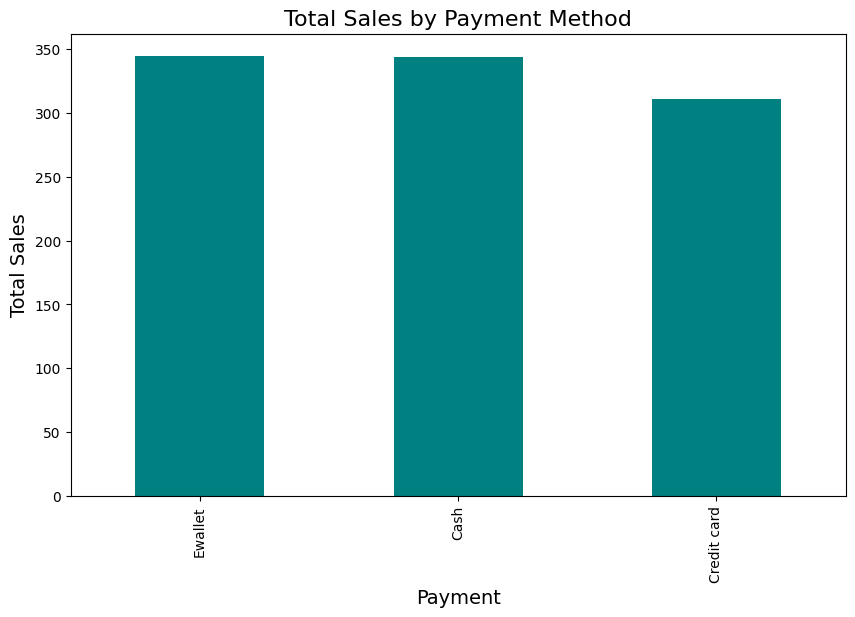

In [41]:
#Visualization of Branches col:
df_Var = df_sales['Payment'].value_counts()

plt.figure(figsize=(10, 6))
df_Var.plot(kind = 'bar', color= 'teal' )

plt.title('Total Sales by Payment Method',  fontsize= 16)
plt.xlabel('Payment', fontsize= 14)
plt.ylabel('Total Sales', fontsize= 14)

plt.show()

#It seems that Cash and Ewallets have higher preference than Credit Card

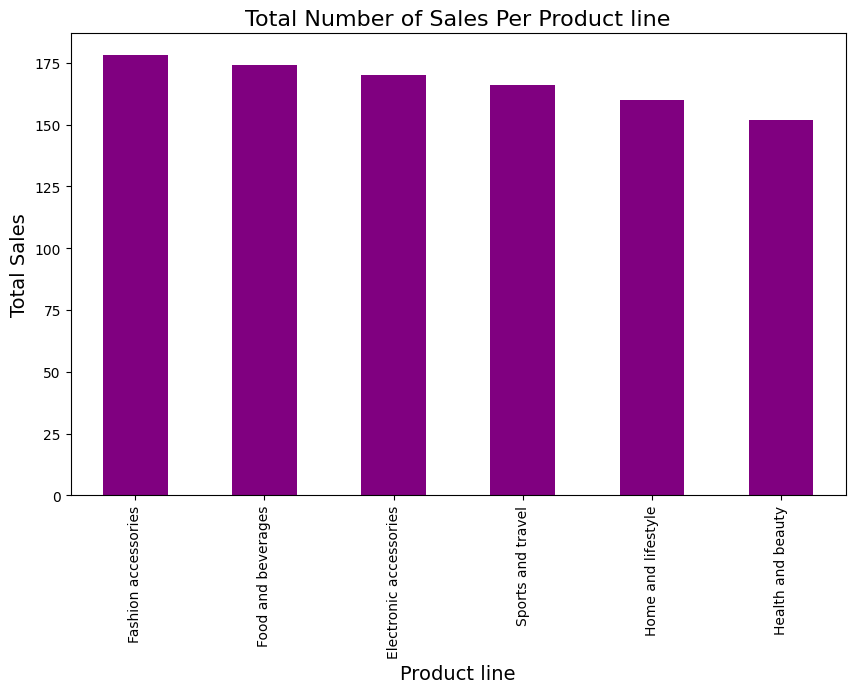

In [32]:
#Visualization of City col:
df_Var = df_sales['Product line'].value_counts()

plt.figure(figsize=(10, 6))
df_Var.plot(kind = 'bar', color= 'purple' )

plt.title('Total Number of Sales Per Product line',  fontsize= 16)
plt.xlabel('Product line', fontsize= 14)
plt.ylabel('Total Sales', fontsize= 14)

plt.show()

#Fashion Accessories line has the highest sales

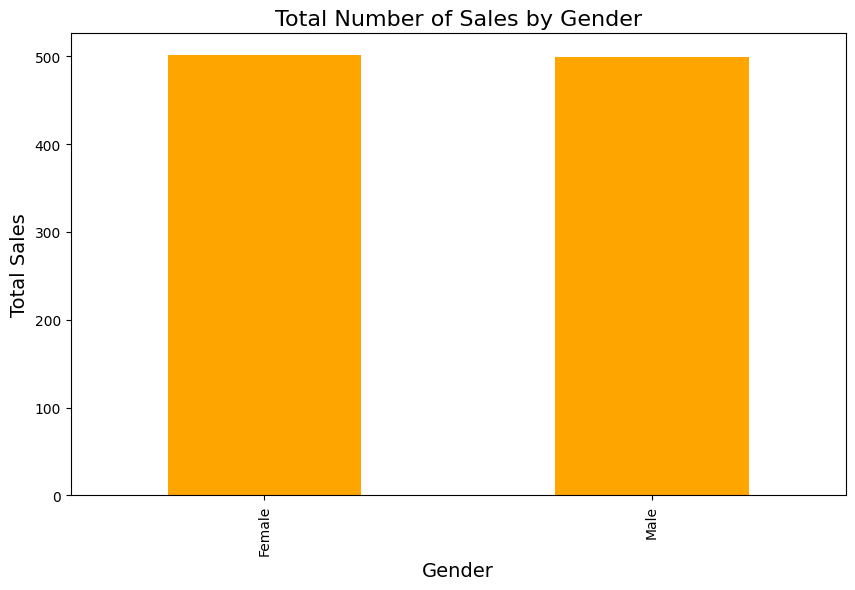

In [29]:
#Visualization of Gender col:
df_Var = df_sales['Gender'].value_counts()

plt.figure(figsize=(10, 6))
df_Var.plot(kind = 'bar', color= 'orange' )

plt.title('Total Number of Sales by Gender',  fontsize= 16)
plt.xlabel('Gender', fontsize= 14)
plt.ylabel('Total Sales', fontsize= 14)

plt.show()

# Males & Females have the same contribution to sales.

###Numeric Variables
`Unit price `
`Quantity`
`Tax 5%`
`Total`
`cogs`
`gross margin percentage`
`gross income `

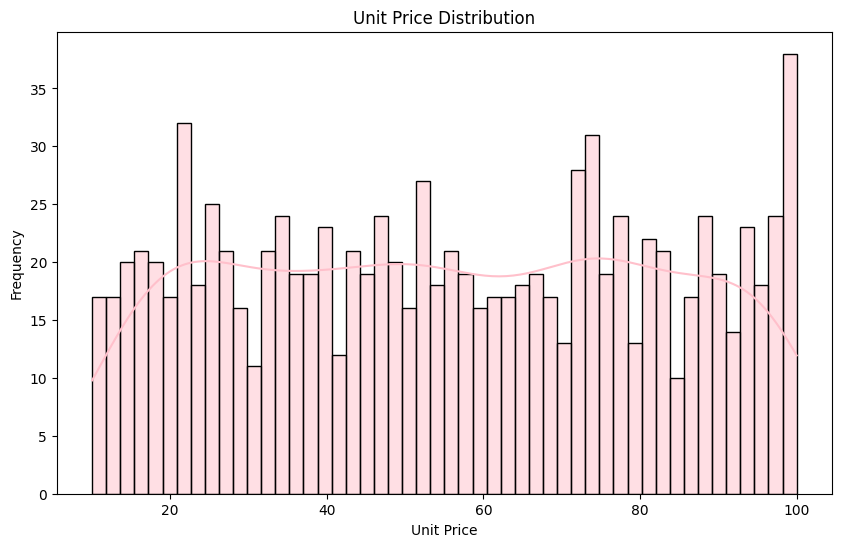

In [35]:
#Visualizing the unit price variable
df_var = df_sales['Unit price']
plt.figure(figsize= (10,6))
sns.histplot(df_var, bins = 50, kde= True, color= 'pink')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.title('Unit Price Distribution')
plt.show()

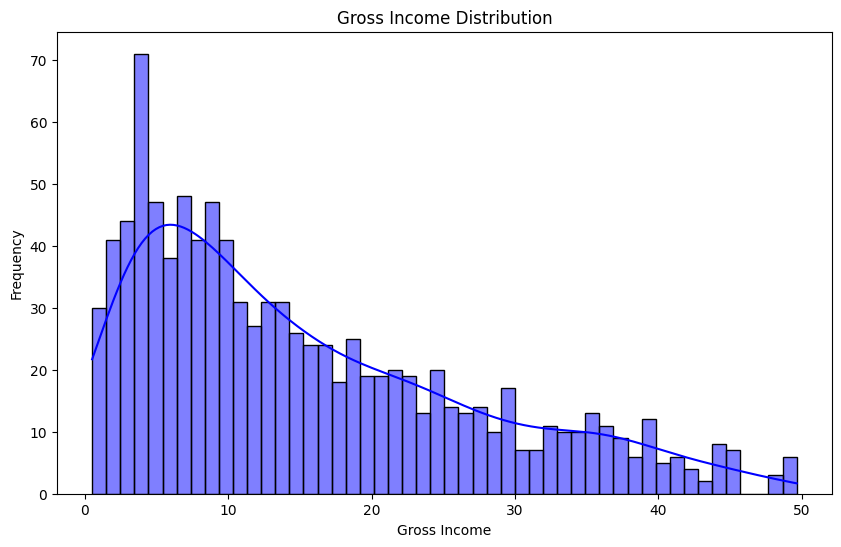

In [38]:
#Visualizing the gross income variable
df_var = df_sales['gross income']
plt.figure(figsize= (10,6))
sns.histplot(df_var, bins = 50, kde= True, color= 'blue')
plt.xlabel('Gross Income')
plt.ylabel('Frequency')
plt.title('Gross Income Distribution')
plt.show()

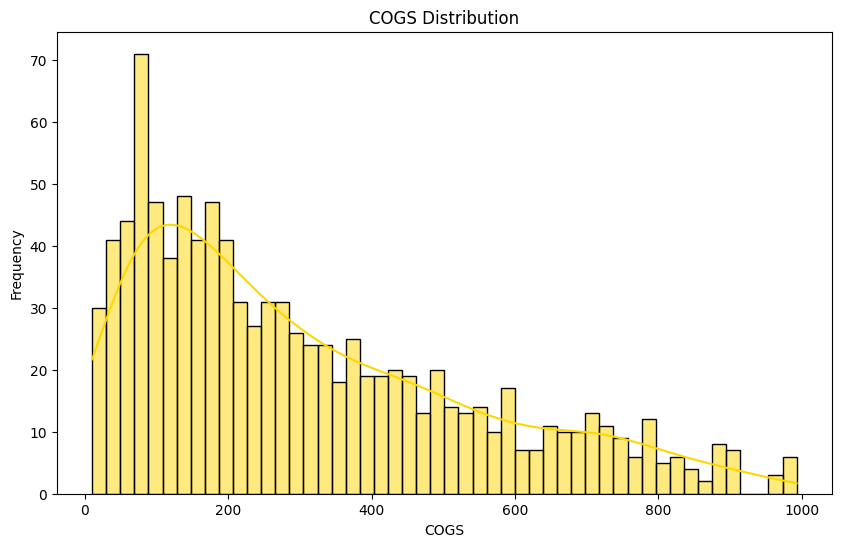

In [45]:
#Visualizing the gross income variable
df_var = df_sales['cogs']
plt.figure(figsize= (10,6))
sns.histplot(df_var, bins = 50, kde= True, color= 'gold')
plt.xlabel('COGS')
plt.ylabel('Frequency')
plt.title('COGS Distribution')
plt.show()

## General Scenario of the data:

`Total` = (`Unit Price` * `Quantity`) + `Tax 5%`

Since the Gross Income is exactly equal to tax 5%, we have an assumption

`COGS` = (`Unit Price` * `Quantity`) - `Tax 5%`

`Gross Income` = `Total` - `COGS`

###Multivariate Analysis: Visualizing relationships among variables:

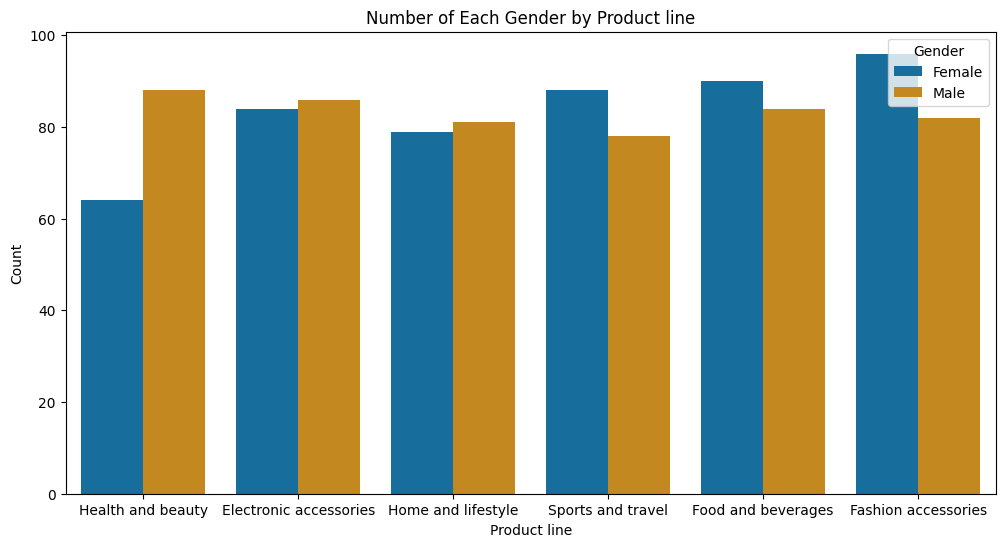

In [49]:
# Visualizing the difference in sales in product line
plt.figure(figsize=(12, 6))
sns.countplot(x='Product line', hue='Gender', data=df_sales, palette = 'colorblind')
plt.title('Number of Each Gender by Product line')
plt.xlabel('Product line')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

/tmp/ipython-input-941859185.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product line', y='gross income', data=df_sales, palette = 'colorblind')


Text(0.5, 0, 'Product line')

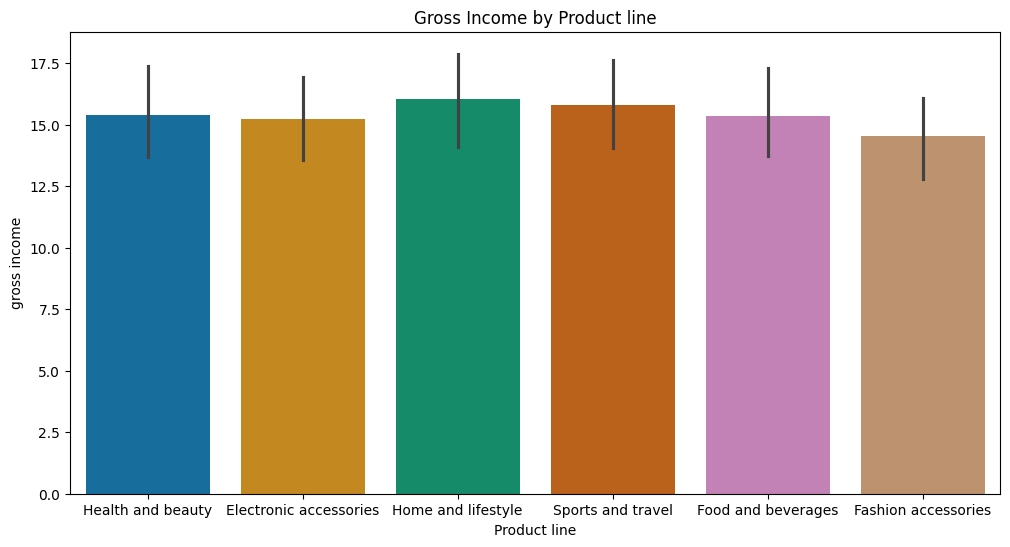

In [55]:
#Visualizing the relationship between Product line & Gross Income
plt.figure(figsize=(12, 6))
sns.barplot(x='Product line', y='gross income', data=df_sales, palette = 'colorblind')
plt.title('Gross Income by Product line')
plt.xlabel('Product line')

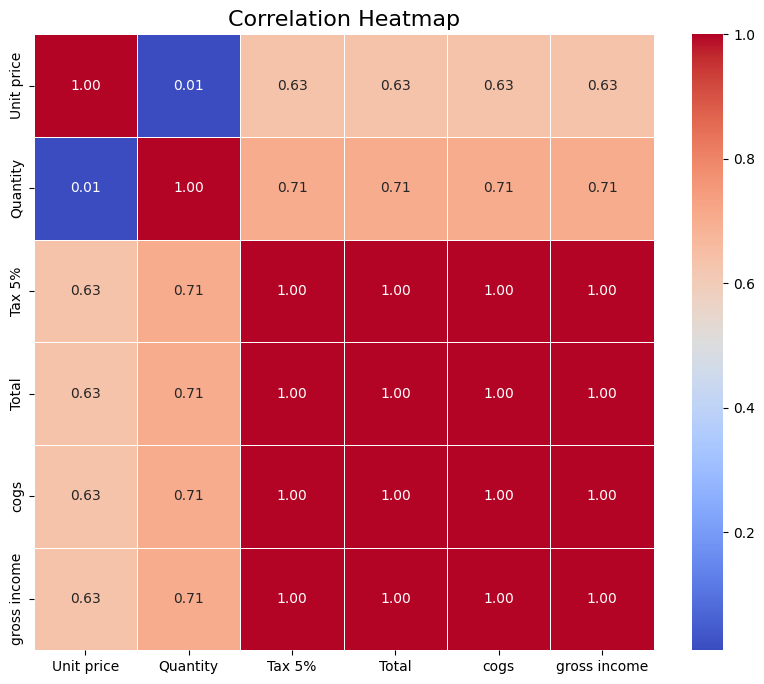

In [66]:
#Finding correlations between variables:
corr_matrix = df_sales[['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross income']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

###Box plots
Numeric variables to show outliers: we will focus on columns that showed variation between the mean and the max from the describe function:`cogs`, `unit_price`, `gross income`

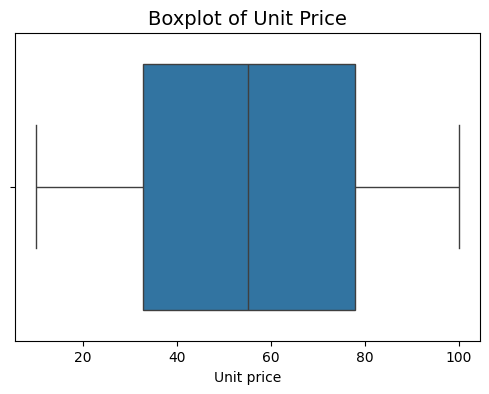

In [71]:
#Boxplot of unit price
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_sales["Unit price"])
plt.title("Boxplot of Unit Price", fontsize=14)
plt.show()

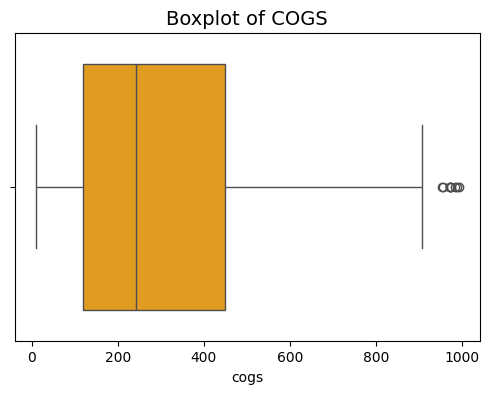

In [79]:
#Boxplot of cogs
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_sales["cogs"], color= 'orange')
plt.title("Boxplot of COGS", fontsize=14)
plt.show()

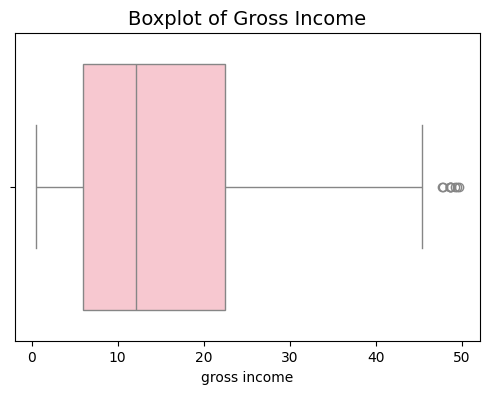

In [78]:
#Boxplot of gross income
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_sales["gross income"], color = 'pink')
plt.title("Boxplot of Gross Income", fontsize=14)
plt.show()

###Outliers Detection

In [75]:
# Gross Income
Q1 = df_sales['gross income'].quantile(0.25)
Q3 = df_sales['gross income'].quantile(0.75)
df_sales[(df_sales['gross income'] < (Q1 - 1.5 * (Q3 - Q1))) | (df_sales['gross income'] > (Q3 + 1.5 * (Q3 - Q1)))].index


Index([166, 167, 350, 357, 422, 557, 699, 792, 996], dtype='int64')

In [76]:
# COGS
Q1 = df_sales['cogs'].quantile(0.25)
Q3 = df_sales['cogs'].quantile(0.75)
df_sales[(df_sales['cogs'] < (Q1 - 1.5 * (Q3 - Q1))) | (df_sales['cogs'] > (Q3 + 1.5 * (Q3 - Q1)))].index


Index([166, 167, 350, 357, 422, 557, 699, 792, 996], dtype='int64')